In [82]:
import numpy as np
import skfuzzy as fuzz

from skfuzzy import control as ctrl

In [83]:
# antecedente = entrada

preco = ctrl.Antecedent(np.arange(40_000, 100_000, 1), 'preco')
consumo = ctrl.Antecedent(np.arange(11, 18, 1), 'consumo')

In [84]:
# consequente = saída

beneficio = ctrl.Consequent(np.arange(0, 11, .5), 'custo_beneficio')

In [85]:
preco.automf(
    number=3,
    names=['baixo', 'medio', 'alto']
)

consumo.automf(
    number=3,
    names=['alto', 'medio', 'baixo'] # ordem decrescente
)

In [86]:
beneficio['baixo'] = fuzz.trimf(beneficio.universe, [0, 2.5, 5])
beneficio['medio'] = fuzz.trimf(beneficio.universe, [2.5, 5, 7.5])
beneficio['alto'] = fuzz.trimf(beneficio.universe, [5, 7.5, 10])

In [87]:
regra1 = ctrl.Rule(preco['baixo'] | consumo['baixo'], beneficio['alto'])
regra2 = ctrl.Rule(preco['baixo'] | consumo['medio'], beneficio['medio'])
regra3 = ctrl.Rule(preco['medio'] | consumo['baixo'], beneficio['medio'])
regra4 = ctrl.Rule(preco['medio'] | consumo['medio'], beneficio['medio'])
regra5 = ctrl.Rule(preco['medio'] | consumo['alto'], beneficio['medio'])
regra6 = ctrl.Rule(preco['alto'] | consumo['medio'], beneficio['medio'])
regra7 = ctrl.Rule(preco['alto'] | consumo['alto'], beneficio['baixo'])
regra8 = ctrl.Rule(preco['baixo'] | consumo['alto'], beneficio['medio'])
regra9 = ctrl.Rule(preco['alto'] | consumo['baixo'], beneficio['medio'])

recomendacao_compra = ctrl.ControlSystem([
    regra1,
    regra2,
    regra3,
    regra4,
    regra5,
    regra6,
    regra7,
    regra8,
    regra9
])

Preco: R$ 50.000,00, consumo: 16 km/l, custo benefício: 3.7499999999999996


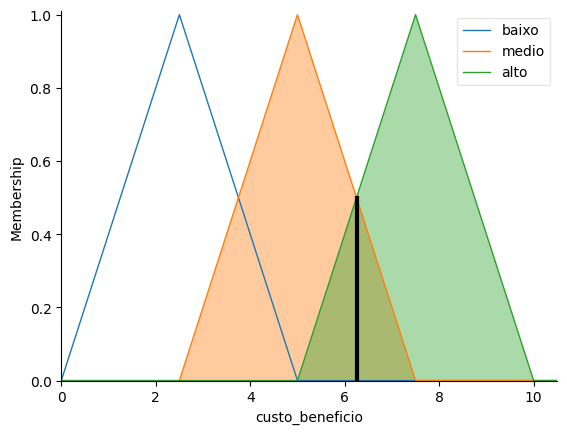

In [98]:
## Aqui, exploramos um custo-benefício médio-alto

medio_alto = ctrl.ControlSystemSimulation(recomendacao_compra)
medio_alto.input['preco'] = 50_000
medio_alto.input['consumo'] = 17
medio_alto.compute()

print(f'Preco: R$ 50.000,00, consumo: 17 km/l, custo benefício: {baixo.output['custo_beneficio']}')
beneficio.view(sim = medio_alto)

Preco: R$ 90.000,00, consumo: 16 km/l, custo benefício: 3.7499999999999996


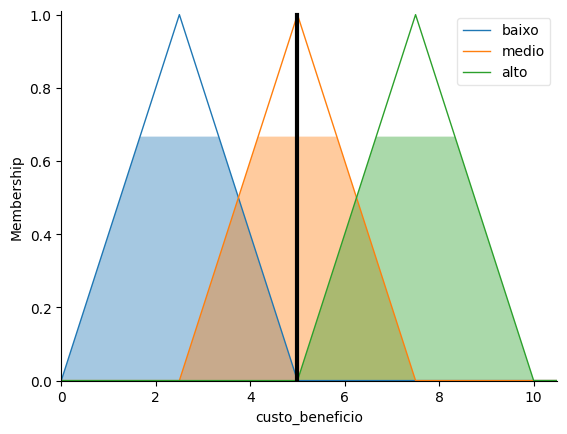

In [89]:
# Aqui, exploramos um custo-benefício médio

medio = ctrl.ControlSystemSimulation(recomendacao_compra)
medio.input['preco'] = 90_000
medio.input['consumo'] = 16
medio.compute()

print(f'Preco: R$ 90.000,00, consumo: 16 km/l, custo benefício: {baixo.output['custo_beneficio']}')
beneficio.view(sim = medio)

Preco: R$ 100.000,00, consumo: 12 km/l, custo benefício: 3.7499999999999996


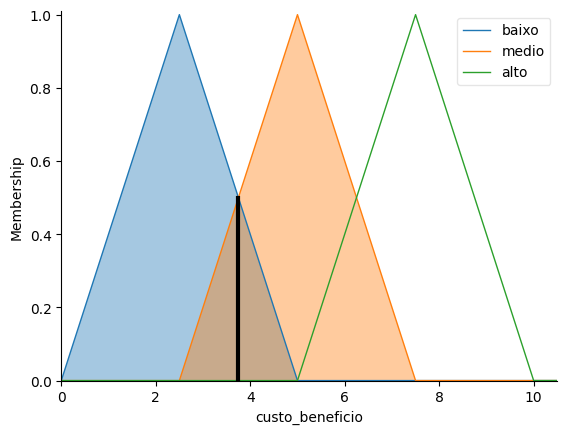

In [97]:
### Aqui, exploramos um custo-benefício médio-baixo

baixo = ctrl.ControlSystemSimulation(recomendacao_compra)
baixo.input['preco'] = 100_000
baixo.input['consumo'] = 12
baixo.compute()

print(f'Preco: R$ 100.000,00, consumo: 12 km/l, custo benefício: {baixo.output['custo_beneficio']}')
beneficio.view(sim = baixo)